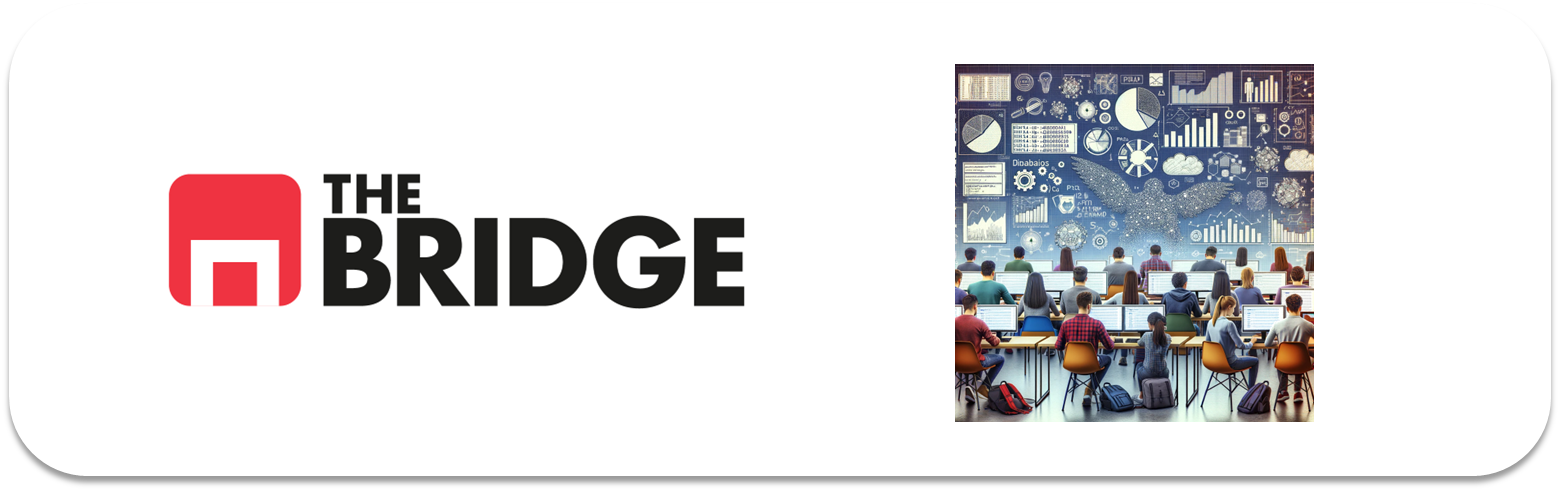

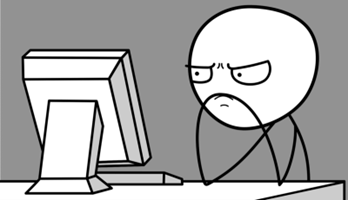

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [3]:
df = pd.read_csv("./data/advertising_ml.csv")

In [4]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   str    
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 78.3 KB


In [6]:
df["Clicked on Ad"].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

In [7]:
df["Male"].value_counts()

Male
0    519
1    481
Name: count, dtype: int64

In [8]:
# la variable age, hay que limpiar, quedarnos solo con los numeros.
df["Age"] = df["Age"].str.extract(r'(\d+)').astype(int)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

Queremos una variable que pueda precedir si un usuario pulsara un anuncio o no (True or False)  
Se trata de un problema de aprendizaje supervisiado (ya que tenemos datos históricos)  
Variable Target - Click on Ad - (0, 1)

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [16]:
def calidad_datos(df):
    resumen = pd.DataFrame({
        'dtype': df.dtypes,
        'nulos': df.isnull().sum(),
        'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'unicos': df.nunique()
    })
    return resumen

print(calidad_datos(df))

                            dtype  nulos  pct_nulos  unicos
Daily Time Spent on Site  float64      0        0.0     900
Age                         int64      0        0.0      43
Area Income               float64      0        0.0    1000
Daily Internet Usage      float64      0        0.0     966
Ad Topic Line                 str      0        0.0    1000
City                          str      0        0.0     969
Male                        int64      0        0.0       2
Country                       str      0        0.0     237
Timestamp                     str      0        0.0    1000
Clicked on Ad               int64      0        0.0       2


In [17]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


,columna,dtype,nulos_pct,cardinalidad
Daily Time Spent on Site,Daily Time Spent on Site,float64,0.0,90.0
Age,Age,int64,0.0,4.3
Area Income,Area Income,float64,0.0,100.0
Daily Internet Usage,Daily Internet Usage,float64,0.0,96.6
Ad Topic Line,Ad Topic Line,str,0.0,100.0
City,City,str,0.0,96.9
Male,Male,int64,0.0,0.2
Country,Country,str,0.0,23.7
Timestamp,Timestamp,str,0.0,100.0
Clicked on Ad,Clicked on Ad,int64,0.0,0.2


In [42]:
# Generación del data dictionary automático
data_dict = pd.DataFrame({
    'columna': df.columns,
    'dtype': df.dtypes.values,
    'nulos_pct': (df.isnull().mean() * 100).round(1).values,
    'cardinalidad': df.nunique()/len(df)*100
})

# Descripción de las variables
descripciones_dict = {
    'Daily Time Spent on Site': 'Tiempo (min) que un usuario está en la web',
    'Age': 'Edad del usuario',
    'Area Income': 'Ingreso anual medio de la zona geográfica',
    'Daily Internet Usage': 'Tiempo de uso de internet diario (min)',
    'Ad Topic Line': 'Título del anuncio mostrado al usuario',
    'City': 'Ciudad del usuario',
    'Male': 'Sexo (1 = hombre, 0 = mujer)',
    'Country': 'País del usuario',
    'Timestamp': 'Fecha y hora de la visita',
    'Clicked on Ad': 'Indica si el usuario hizo clic en el anuncio'
}

# Clasificación estadística
tipo_dict = {
    'Daily Time Spent on Site': 'Numérica continua',
    'Age': 'Numérica discreta',
    'Area Income': 'Numérica continua',
    'Daily Internet Usage': 'Numérica continua',
    'Ad Topic Line': 'Categórica nominal (texto)',
    'City': 'Categórica nominal',
    'Male': 'Categórica binaria',
    'Country': 'Categórica nominal',
    'Timestamp': 'Temporal',
    'Clicked on Ad': 'Categórica binaria (target)'
}

# Mapeo
data_dict['descripcion'] = data_dict['columna'].map(descripciones_dict)
data_dict['clasificacion_estadistica'] = data_dict['columna'].map(tipo_dict)

# Reordenar columnas
data_dict = data_dict[['columna', 'descripcion', 'clasificacion_estadistica', 'dtype', 'nulos_pct', 'cardinalidad']]

# Rerganizar el indice
data_dict = data_dict.set_index("columna")
display(data_dict)



,descripcion,clasificacion_estadistica,dtype,nulos_pct,cardinalidad
columna,,,,,
Daily Time Spent on Site,Tiempo (min) que un usuario está en la web,Numérica continua,float64,0.0,90.0
Age,Edad del usuario,Numérica discreta,int64,0.0,4.3
Area Income,Ingreso anual medio de la zona geográfica,Numérica continua,float64,0.0,100.0
Daily Internet Usage,Tiempo de uso de internet diario (min),Numérica continua,float64,0.0,96.6
Ad Topic Line,Título del anuncio mostrado al usuario,Categórica nominal (texto),str,0.0,100.0
City,Ciudad del usuario,Categórica nominal,str,0.0,96.9
Male,"Sexo (1 = hombre, 0 = mujer)",Categórica binaria,int64,0.0,0.2
Country,País del usuario,Categórica nominal,str,0.0,23.7
Timestamp,Fecha y hora de la visita,Temporal,datetime64[us],0.0,100.0


### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [36]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])


### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [34]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

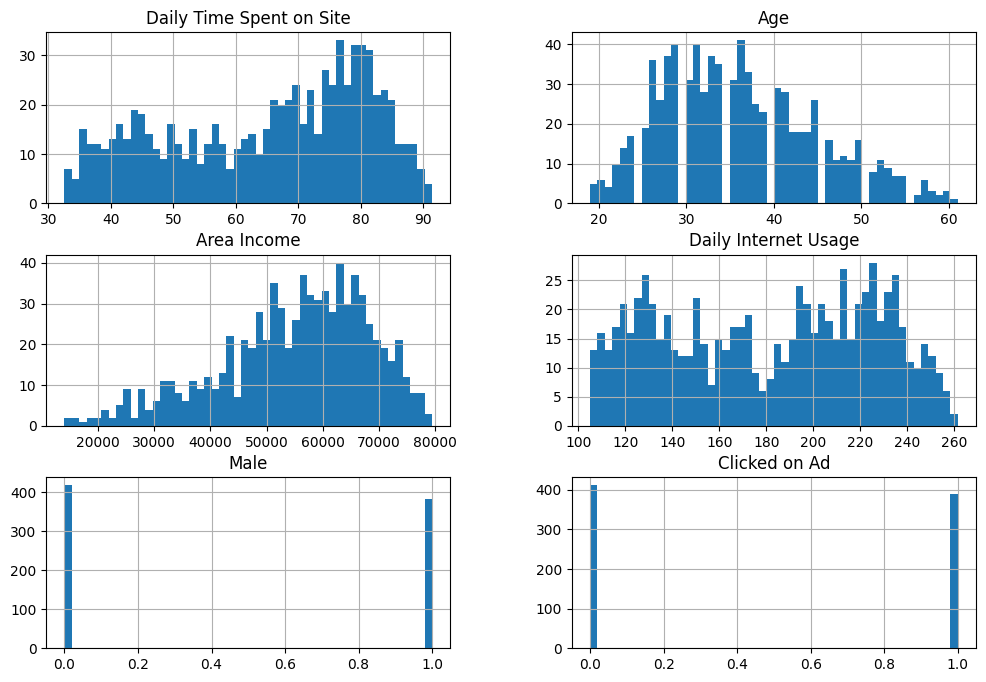

In [39]:
 # La forma de generar histogramas de una sola vez para las variables numéricas de un dataset
train_set.hist(bins=50, figsize=(12, 8))
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

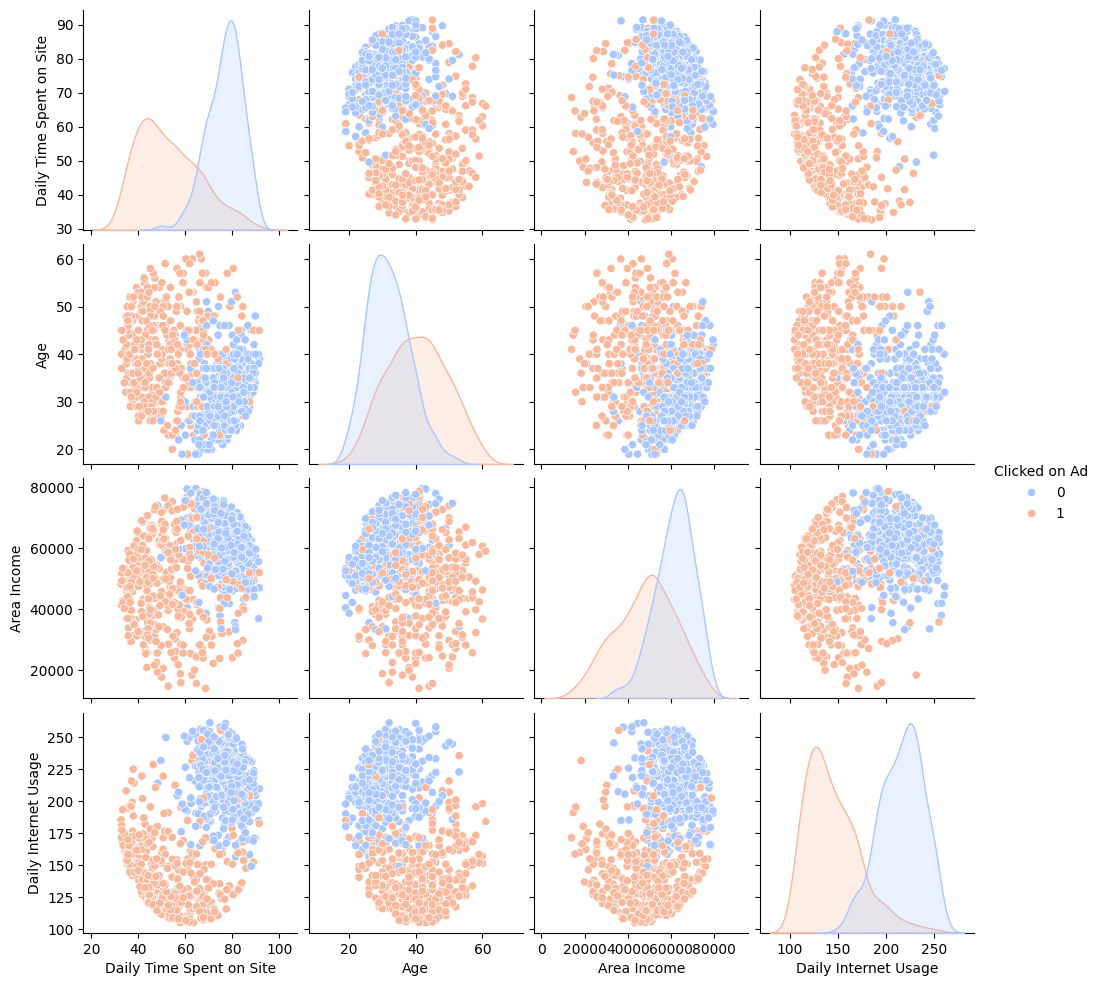

In [44]:
# Selección de variables continuas + target
variables_continuas = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage",
    "Clicked on Ad"
]

df_pair = train_set[variables_continuas]

# PairPlot
sns.pairplot(
    df_pair,
    hue="Clicked on Ad",
    diag_kind="kde",
    palette="coolwarm"
)

plt.show()


### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

In [ ]:
# seleccionamos las 4 variables como features